# Raw TSV EDA

Exploratory data analysis for all TSV files in `data/raw`.

Main goals:
- inventory all raw files;
- inspect schema, missing values, duplicates, keys, and date ranges;
- run relationship checks for common Wide World Importers tables;
- create quick sales, purchasing, and warehouse summaries.

In [32]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_DIR = Path('./../data/raw')
REPORT_DIR = Path('./reports/eda')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Set to an integer such as 100_000 if the machine is low on memory.
NROWS = None

print(f'Data directory: {DATA_DIR.resolve()}')

Data directory: E:\NAM3\PTDL\WWI\data\processed\raw_csv_normalized


## 1. File Inventory

In [33]:
csv_files = sorted(DATA_DIR.glob('*.tsv'))

if not csv_files:
    raise FileNotFoundError(f'No TSV files found in {DATA_DIR.resolve()}')

file_inventory = pd.DataFrame({
    'file_name': [p.name for p in csv_files],
    'table_name': [p.stem for p in csv_files],
    'domain': [p.stem.split('_', 1)[0] if '_' in p.stem else 'Unknown' for p in csv_files],
    'is_archive': [p.stem.endswith('_Archive') for p in csv_files],
    'size_mb': [p.stat().st_size / 1024**2 for p in csv_files],
})

display(file_inventory.sort_values(['domain', 'table_name']).reset_index(drop=True))
print(f'TSV file count: {len(csv_files)}')
print(f'Total raw size: {file_inventory.size_mb.sum():,.2f} MB')

,file_name,table_name,domain,is_archive,size_mb
0,Application_Cities.csv,Application_Cities,Application,False,4.5124
1,Application_Cities_Archive.csv,Application_Cities_Archive,Application,True,0.0034
2,Application_Countries.csv,Application_Countries,Application,False,0.0002
3,Application_Countries_Archive.csv,Application_Countries_Archive,Application,True,0.0002
4,Application_DeliveryMethods.csv,Application_DeliveryMethods,Application,False,0.0008
5,Application_DeliveryMethods_Archive.csv,Application_DeliveryMethods_Archive,Application,True,0.0001
6,Application_PaymentMethods.csv,Application_PaymentMethods,Application,False,0.0003
7,Application_PaymentMethods_Archive.csv,Application_PaymentMethods_Archive,Application,True,0.0001
8,Application_People.csv,Application_People,Application,False,0.2379
9,Application_People_Archive.csv,Application_People_Archive,Application,True,0.3485


CSV file count: 48
Total raw size: 502.48 MB


## 2. Load Data

In [34]:
def read_tsv_safely(path: Path, nrows=None) -> pd.DataFrame:
    """Read a TSV with a small fallback list for common encodings."""
    encodings = ['utf-8', 'utf-8-sig', 'latin1']
    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(path, sep='\t', low_memory=False, nrows=nrows, encoding=encoding)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise last_error


tables = {}
load_errors = []

for path in csv_files:
    try:
        df = read_tsv_safely(path, nrows=NROWS)
        tables[path.stem] = df
        print(f'Loaded {path.name}: {len(df):,} rows x {df.shape[1]:,} cols')
    except Exception as exc:
        load_errors.append({'file_name': path.name, 'error': repr(exc)})
        print(f'FAILED {path.name}: {exc!r}')

load_errors = pd.DataFrame(load_errors)
if not load_errors.empty:
    display(load_errors)

Loaded Application_Cities.csv: 37,940 rows x 8 cols
Loaded Application_Cities_Archive.csv: 28 rows x 8 cols
Loaded Application_Countries.csv: 0 rows x 14 cols
Loaded Application_Countries_Archive.csv: 0 rows x 14 cols
Loaded Application_DeliveryMethods.csv: 10 rows x 5 cols
Loaded Application_DeliveryMethods_Archive.csv: 1 rows x 5 cols
Loaded Application_PaymentMethods.csv: 4 rows x 5 cols
Loaded Application_PaymentMethods_Archive.csv: 1 rows x 5 cols
Loaded Application_People.csv: 1,111 rows x 21 cols
Loaded Application_People_Archive.csv: 961 rows x 21 cols
Loaded Application_StateProvinces.csv: 53 rows x 10 cols
Loaded Application_StateProvinces_Archive.csv: 104 rows x 10 cols
Loaded Application_SystemParameters.csv: 1 rows x 13 cols
Loaded Application_TransactionTypes.csv: 13 rows x 5 cols
Loaded Application_TransactionTypes_Archive.csv: 1 rows x 5 cols
Loaded Purchasing_PurchaseOrderLines.csv: 8,367 rows x 12 cols
Loaded Purchasing_PurchaseOrders.csv: 2,074 rows x 12 cols
Loaded 

## 3. Table Overview

In [35]:
def table_overview(name: str, df: pd.DataFrame) -> dict:
    missing_cells = int(df.isna().sum().sum())
    total_cells = int(df.shape[0] * df.shape[1])
    return {
        'table_name': name,
        'domain': name.split('_', 1)[0] if '_' in name else 'Unknown',
        'is_archive': name.endswith('_Archive'),
        'rows': len(df),
        'columns': df.shape[1],
        'duplicate_rows': int(df.duplicated().sum()),
        'missing_cells': missing_cells,
        'missing_cell_pct': missing_cells / total_cells if total_cells else 0,
        'memory_mb': df.memory_usage(deep=True).sum() / 1024**2,
    }


table_summary = pd.DataFrame([table_overview(name, df) for name, df in tables.items()])
table_summary = table_summary.sort_values(['domain', 'table_name']).reset_index(drop=True)
display(table_summary)

table_summary.to_csv(REPORT_DIR / 'table_summary.csv', index=False)
print(f'Saved: {REPORT_DIR / "table_summary.csv"}')

,table_name,domain,is_archive,rows,columns,duplicate_rows,missing_cells,missing_cell_pct,memory_mb
0,Application_Cities,Application,False,37940,8,0,11048,0.0364,12.1087
1,Application_Cities_Archive,Application,True,28,8,0,11,0.0491,0.0091
2,Application_Countries,Application,False,0,14,0,0,0.0000,0.0001
3,Application_Countries_Archive,Application,True,0,14,0,0,0.0000,0.0001
4,Application_DeliveryMethods,Application,False,10,5,0,0,0.0000,0.0023
5,Application_DeliveryMethods_Archive,Application,True,1,5,0,0,0.0000,0.0003
6,Application_PaymentMethods,Application,False,4,5,0,0,0.0000,0.0010
7,Application_PaymentMethods_Archive,Application,True,1,5,0,0,0.0000,0.0003
8,Application_People,Application,False,1111,21,0,5181,0.2221,0.8793
9,Application_People_Archive,Application,True,961,21,0,3147,0.1559,0.9115


Saved: \reports\eda\table_summary.csv


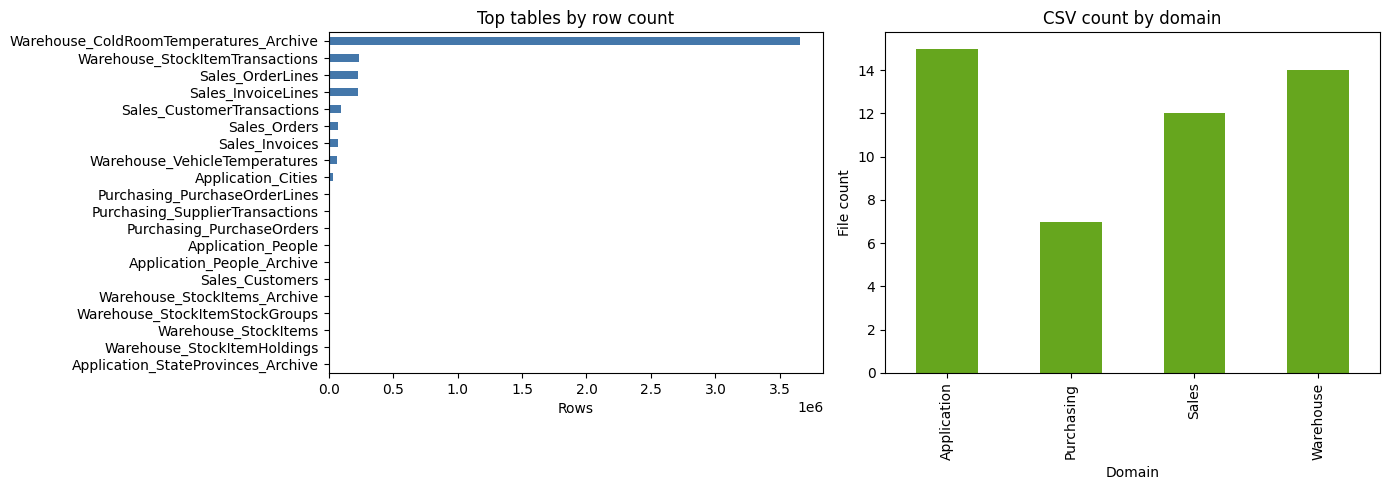

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

table_summary.sort_values('rows', ascending=False).head(20).plot.barh(
    x='table_name', y='rows', ax=axes[0], legend=False, color='#4477AA'
)
axes[0].invert_yaxis()
axes[0].set_title('Top tables by row count')
axes[0].set_xlabel('Rows')
axes[0].set_ylabel('')

domain_counts = table_summary.groupby('domain', as_index=False)['table_name'].count()
domain_counts.plot.bar(x='domain', y='table_name', ax=axes[1], legend=False, color='#66A61E')
axes[1].set_title('CSV count by domain')
axes[1].set_xlabel('Domain')
axes[1].set_ylabel('File count')

plt.tight_layout()
plt.show()

## 4. Column Profile

In [37]:
DATE_HINTS = ('date', 'time', 'validfrom', 'validto', 'confirmed', 'expected', 'delivery')


def looks_like_datetime(column_name: str, series: pd.Series) -> bool:
    name_hit = any(hint in column_name.lower() for hint in DATE_HINTS)
    if not name_hit and not pd.api.types.is_object_dtype(series):
        return False
    sample = series.dropna().astype(str).head(200)
    if sample.empty:
        return name_hit
    parsed = pd.to_datetime(sample, errors='coerce')
    return parsed.notna().mean() >= 0.8


def column_profile(name: str, df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for col in df.columns:
        s = df[col]
        non_null = int(s.notna().sum())
        unique_count = int(s.nunique(dropna=True))
        is_numeric = pd.api.types.is_numeric_dtype(s)
        is_datetime_like = looks_like_datetime(col, s)
        records.append({
            'table_name': name,
            'column_name': col,
            'dtype': str(s.dtype),
            'non_null': non_null,
            'missing': int(s.isna().sum()),
            'missing_pct': float(s.isna().mean()),
            'unique': unique_count,
            'unique_pct': unique_count / non_null if non_null else np.nan,
            'is_numeric': is_numeric,
            'is_datetime_like': is_datetime_like,
            'sample_values': ', '.join(map(str, s.dropna().astype(str).head(3).tolist())),
        })
    return pd.DataFrame(records)


profiles = pd.concat([column_profile(name, df) for name, df in tables.items()], ignore_index=True)
display(profiles.sort_values(['table_name', 'column_name']))

profiles.to_csv(REPORT_DIR / 'column_profile.csv', index=False)
print(f'Saved: {REPORT_DIR / "column_profile.csv"}')

,table_name,column_name,dtype,non_null,missing,missing_pct,unique,unique_pct,is_numeric,is_datetime_like,sample_values
0,Application_Cities,CityID,int64,37940,0,0.0000,37940,1.0000,True,False,"1, 3, 4"
1,Application_Cities,CityName,object,37940,0,0.0000,23279,0.6136,False,False,"Aaronsburg, Abanda, Abbeville"
5,Application_Cities,LastEditedBy,int64,37940,0,0.0000,4,0.0001,True,False,"1, 1, 1"
4,Application_Cities,LatestRecordedPopulation,float64,26892,11048,0.2912,9324,0.3467,True,False,"613.0, 192.0, 5237.0"
3,Application_Cities,Location,object,37940,0,0.0000,37939,1.0000,False,False,"E6100000010C07E11B542C73444087C09140035D53C0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
555,Warehouse_VehicleTemperatures,IsCompressed,int64,65998,0,0.0000,1,0.0000,True,False,"0, 0, 0"
552,Warehouse_VehicleTemperatures,RecordedWhen,object,65998,0,0.0000,32999,0.5000,False,True,"2016-05-27 12:31:20.0000000, 2016-05-27 12:35:..."
553,Warehouse_VehicleTemperatures,Temperature,float64,65998,0,0.0000,201,0.0030,True,False,"4.53, 3.36, 3.69"
550,Warehouse_VehicleTemperatures,VehicleRegistration,object,65998,0,0.0000,1,0.0000,False,False,"WWI-321-A, WWI-321-A, WWI-321-A"


Saved: \reports\eda\column_profile.csv


,table_name,column_name,dtype,missing,missing_pct,sample_values
556,Warehouse_VehicleTemperatures,CompressedSensorData,float64,65998,1.0000,
169,Purchasing_PurchaseOrders,Comments,float64,2074,1.0000,
429,Sales_SpecialDeals,UnitPrice,float64,2,1.0000,
234,Purchasing_Suppliers_Archive,DeliveryLocation,float64,9,1.0000,
427,Sales_SpecialDeals,DiscountAmount,float64,2,1.0000,
422,Sales_SpecialDeals,CustomerCategoryID,float64,2,1.0000,
420,Sales_SpecialDeals,CustomerID,float64,2,1.0000,
419,Sales_SpecialDeals,StockItemID,float64,2,1.0000,
414,Sales_Orders,InternalComments,float64,73595,1.0000,
413,Sales_Orders,DeliveryInstructions,float64,73595,1.0000,


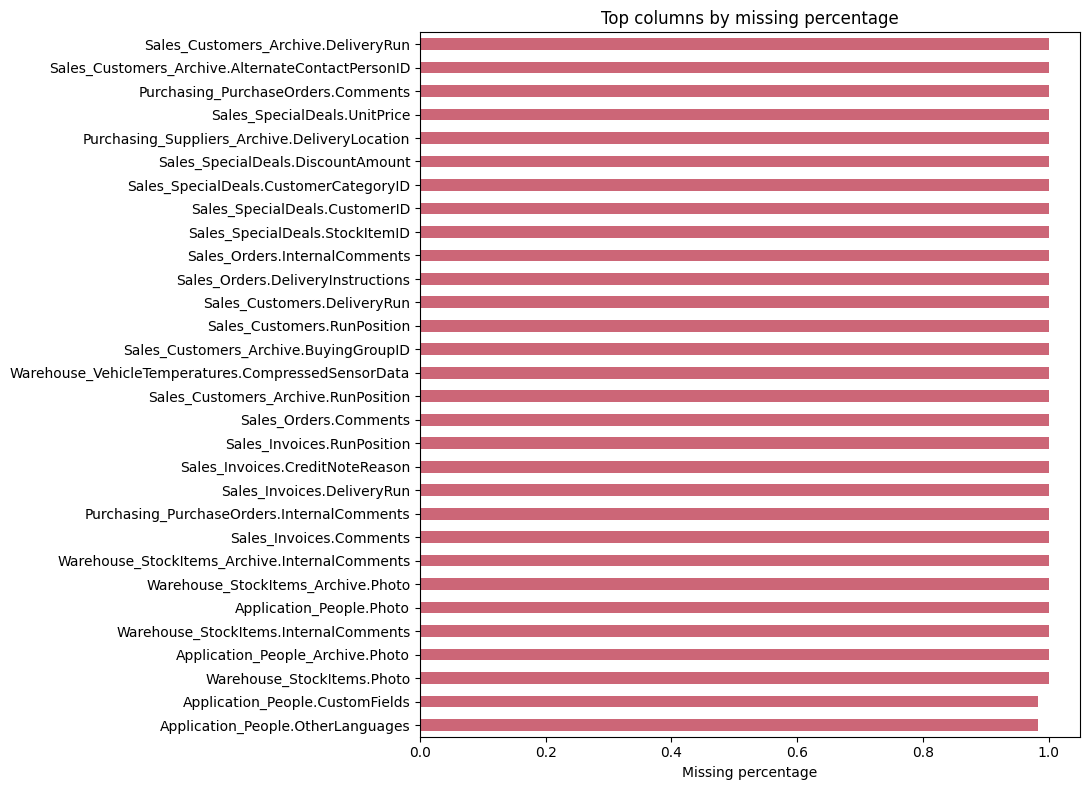

In [38]:
missing_columns = profiles[profiles['missing'] > 0].sort_values('missing_pct', ascending=False)
display(missing_columns[['table_name', 'column_name', 'dtype', 'missing', 'missing_pct', 'sample_values']].head(80))

if not missing_columns.empty:
    plot_data = missing_columns.head(30).assign(label=lambda x: x['table_name'] + '.' + x['column_name'])
    ax = plot_data.sort_values('missing_pct').plot.barh(
        x='label', y='missing_pct', figsize=(11, 8), legend=False, color='#CC6677'
    )
    ax.set_title('Top columns by missing percentage')
    ax.set_xlabel('Missing percentage')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

## 5. Primary Key and Duplicate Checks

In [39]:
KEY_COLUMNS = {
    'Application_Cities': ['CityID'],
    'Application_Cities_Archive': ['CityID', 'ValidFrom'],
    'Application_Countries': ['CountryID'],
    'Application_Countries_Archive': ['CountryID', 'ValidFrom'],
    'Application_DeliveryMethods': ['DeliveryMethodID'],
    'Application_DeliveryMethods_Archive': ['DeliveryMethodID', 'ValidFrom'],
    'Application_PaymentMethods': ['PaymentMethodID'],
    'Application_PaymentMethods_Archive': ['PaymentMethodID', 'ValidFrom'],
    'Application_People': ['PersonID'],
    'Application_People_Archive': ['PersonID', 'ValidFrom'],
    'Application_StateProvinces': ['StateProvinceID'],
    'Application_StateProvinces_Archive': ['StateProvinceID', 'ValidFrom'],
    'Application_TransactionTypes': ['TransactionTypeID'],
    'Application_TransactionTypes_Archive': ['TransactionTypeID', 'ValidFrom'],
    'Purchasing_PurchaseOrderLines': ['PurchaseOrderLineID'],
    'Purchasing_PurchaseOrders': ['PurchaseOrderID'],
    'Purchasing_SupplierCategories': ['SupplierCategoryID'],
    'Purchasing_SupplierCategories_Archive': ['SupplierCategoryID', 'ValidFrom'],
    'Purchasing_Suppliers': ['SupplierID'],
    'Purchasing_Suppliers_Archive': ['SupplierID', 'ValidFrom'],
    'Purchasing_SupplierTransactions': ['SupplierTransactionID'],
    'Sales_BuyingGroups': ['BuyingGroupID'],
    'Sales_BuyingGroups_Archive': ['BuyingGroupID', 'ValidFrom'],
    'Sales_CustomerCategories': ['CustomerCategoryID'],
    'Sales_CustomerCategories_Archive': ['CustomerCategoryID', 'ValidFrom'],
    'Sales_Customers': ['CustomerID'],
    'Sales_Customers_Archive': ['CustomerID', 'ValidFrom'],
    'Sales_CustomerTransactions': ['CustomerTransactionID'],
    'Sales_InvoiceLines': ['InvoiceLineID'],
    'Sales_Invoices': ['InvoiceID'],
    'Sales_OrderLines': ['OrderLineID'],
    'Sales_Orders': ['OrderID'],
    'Sales_SpecialDeals': ['SpecialDealID'],
    'Warehouse_ColdRoomTemperatures': ['ColdRoomTemperatureID'],
    'Warehouse_ColdRoomTemperatures_Archive': ['ColdRoomTemperatureID', 'ValidFrom'],
    'Warehouse_Colors': ['ColorID'],
    'Warehouse_Colors_Archive': ['ColorID', 'ValidFrom'],
    'Warehouse_PackageTypes': ['PackageTypeID'],
    'Warehouse_PackageTypes_Archive': ['PackageTypeID', 'ValidFrom'],
    'Warehouse_StockGroups': ['StockGroupID'],
    'Warehouse_StockGroups_Archive': ['StockGroupID', 'ValidFrom'],
    'Warehouse_StockItemHoldings': ['StockItemID'],
    'Warehouse_StockItems': ['StockItemID'],
    'Warehouse_StockItems_Archive': ['StockItemID', 'ValidFrom'],
    'Warehouse_StockItemStockGroups': ['StockItemID', 'StockGroupID'],
    'Warehouse_StockItemTransactions': ['StockItemTransactionID'],
    'Warehouse_VehicleTemperatures': ['VehicleTemperatureID'],
}


def check_key(table_name: str, key_cols: list[str]) -> dict:
    df = tables.get(table_name)
    if df is None:
        return {'table_name': table_name, 'key_columns': ', '.join(key_cols), 'status': 'table_missing'}
    missing_cols = [col for col in key_cols if col not in df.columns]
    if missing_cols:
        return {
            'table_name': table_name,
            'key_columns': ', '.join(key_cols),
            'status': 'key_column_missing',
            'missing_columns': ', '.join(missing_cols),
        }
    key_null_rows = int(df[key_cols].isna().any(axis=1).sum())
    duplicate_key_rows = int(df.duplicated(subset=key_cols, keep=False).sum())
    return {
        'table_name': table_name,
        'key_columns': ', '.join(key_cols),
        'status': 'ok' if key_null_rows == 0 and duplicate_key_rows == 0 else 'review',
        'rows': len(df),
        'key_null_rows': key_null_rows,
        'duplicate_key_rows': duplicate_key_rows,
    }


key_checks = pd.DataFrame([check_key(name, cols) for name, cols in KEY_COLUMNS.items() if name in tables])
display(key_checks.sort_values(['status', 'table_name']))
key_checks.to_csv(REPORT_DIR / 'key_checks.csv', index=False)
print(f'Saved: {REPORT_DIR / "key_checks.csv"}')

,table_name,key_columns,status,rows,key_null_rows,duplicate_key_rows
0,Application_Cities,CityID,ok,37940,0,0
1,Application_Cities_Archive,"CityID, ValidFrom",ok,28,0,0
2,Application_Countries,CountryID,ok,0,0,0
3,Application_Countries_Archive,"CountryID, ValidFrom",ok,0,0,0
4,Application_DeliveryMethods,DeliveryMethodID,ok,10,0,0
5,Application_DeliveryMethods_Archive,"DeliveryMethodID, ValidFrom",ok,1,0,0
6,Application_PaymentMethods,PaymentMethodID,ok,4,0,0
7,Application_PaymentMethods_Archive,"PaymentMethodID, ValidFrom",ok,1,0,0
8,Application_People,PersonID,ok,1111,0,0
10,Application_StateProvinces,StateProvinceID,ok,53,0,0


Saved: \reports\eda\key_checks.csv


## 6. Relationship Checks

In [40]:
RELATIONSHIPS = [
    ('Application_StateProvinces', 'CountryID', 'Application_Countries', 'CountryID'),
    ('Application_Cities', 'StateProvinceID', 'Application_StateProvinces', 'StateProvinceID'),
    ('Sales_Customers', 'CustomerCategoryID', 'Sales_CustomerCategories', 'CustomerCategoryID'),
    ('Sales_Customers', 'BuyingGroupID', 'Sales_BuyingGroups', 'BuyingGroupID'),
    ('Sales_Customers', 'DeliveryCityID', 'Application_Cities', 'CityID'),
    ('Sales_Customers', 'PostalCityID', 'Application_Cities', 'CityID'),
    ('Sales_Invoices', 'CustomerID', 'Sales_Customers', 'CustomerID'),
    ('Sales_Invoices', 'BillToCustomerID', 'Sales_Customers', 'CustomerID'),
    ('Sales_Invoices', 'OrderID', 'Sales_Orders', 'OrderID'),
    ('Sales_InvoiceLines', 'InvoiceID', 'Sales_Invoices', 'InvoiceID'),
    ('Sales_InvoiceLines', 'StockItemID', 'Warehouse_StockItems', 'StockItemID'),
    ('Sales_Orders', 'CustomerID', 'Sales_Customers', 'CustomerID'),
    ('Sales_OrderLines', 'OrderID', 'Sales_Orders', 'OrderID'),
    ('Sales_OrderLines', 'StockItemID', 'Warehouse_StockItems', 'StockItemID'),
    ('Sales_OrderLines', 'PackageTypeID', 'Warehouse_PackageTypes', 'PackageTypeID'),
    ('Purchasing_Suppliers', 'SupplierCategoryID', 'Purchasing_SupplierCategories', 'SupplierCategoryID'),
    ('Purchasing_PurchaseOrders', 'SupplierID', 'Purchasing_Suppliers', 'SupplierID'),
    ('Purchasing_PurchaseOrderLines', 'PurchaseOrderID', 'Purchasing_PurchaseOrders', 'PurchaseOrderID'),
    ('Purchasing_PurchaseOrderLines', 'StockItemID', 'Warehouse_StockItems', 'StockItemID'),
    ('Purchasing_SupplierTransactions', 'SupplierID', 'Purchasing_Suppliers', 'SupplierID'),
    ('Warehouse_StockItems', 'SupplierID', 'Purchasing_Suppliers', 'SupplierID'),
    ('Warehouse_StockItems', 'UnitPackageID', 'Warehouse_PackageTypes', 'PackageTypeID'),
    ('Warehouse_StockItems', 'OuterPackageID', 'Warehouse_PackageTypes', 'PackageTypeID'),
    ('Warehouse_StockItemHoldings', 'StockItemID', 'Warehouse_StockItems', 'StockItemID'),
    ('Warehouse_StockItemStockGroups', 'StockItemID', 'Warehouse_StockItems', 'StockItemID'),
    ('Warehouse_StockItemStockGroups', 'StockGroupID', 'Warehouse_StockGroups', 'StockGroupID'),
]


def relationship_check(child_table, child_key, parent_table, parent_key):
    child = tables.get(child_table)
    parent = tables.get(parent_table)
    base = {
        'child_table': child_table,
        'child_key': child_key,
        'parent_table': parent_table,
        'parent_key': parent_key,
    }
    if child is None or parent is None:
        return {**base, 'status': 'table_missing'}
    if child_key not in child.columns or parent_key not in parent.columns:
        return {**base, 'status': 'column_missing'}
    child_values = child[child_key].dropna()
    parent_values = set(parent[parent_key].dropna().unique())
    orphan_mask = ~child_values.isin(parent_values)
    orphan_count = int(orphan_mask.sum())
    return {
        **base,
        'status': 'ok' if orphan_count == 0 else 'review',
        'nonnull_child_rows': int(child_values.shape[0]),
        'orphan_rows': orphan_count,
        'orphan_pct': orphan_count / child_values.shape[0] if child_values.shape[0] else 0,
        'sample_orphan_values': ', '.join(map(str, child_values[orphan_mask].drop_duplicates().head(10).tolist())),
    }


relationship_checks = pd.DataFrame([relationship_check(*rel) for rel in RELATIONSHIPS])
display(relationship_checks.sort_values(['status', 'orphan_rows'], ascending=[True, False]))
relationship_checks.to_csv(REPORT_DIR / 'relationship_checks.csv', index=False)
print(f'Saved: {REPORT_DIR / "relationship_checks.csv"}')

,child_table,child_key,parent_table,parent_key,status,nonnull_child_rows,orphan_rows,orphan_pct,sample_orphan_values
1,Application_Cities,StateProvinceID,Application_StateProvinces,StateProvinceID,ok,37940,0,0.0000,
2,Sales_Customers,CustomerCategoryID,Sales_CustomerCategories,CustomerCategoryID,ok,663,0,0.0000,
3,Sales_Customers,BuyingGroupID,Sales_BuyingGroups,BuyingGroupID,ok,402,0,0.0000,
4,Sales_Customers,DeliveryCityID,Application_Cities,CityID,ok,663,0,0.0000,
5,Sales_Customers,PostalCityID,Application_Cities,CityID,ok,663,0,0.0000,
6,Sales_Invoices,CustomerID,Sales_Customers,CustomerID,ok,70510,0,0.0000,
7,Sales_Invoices,BillToCustomerID,Sales_Customers,CustomerID,ok,70510,0,0.0000,
8,Sales_Invoices,OrderID,Sales_Orders,OrderID,ok,70510,0,0.0000,
9,Sales_InvoiceLines,InvoiceID,Sales_Invoices,InvoiceID,ok,228265,0,0.0000,
10,Sales_InvoiceLines,StockItemID,Warehouse_StockItems,StockItemID,ok,228265,0,0.0000,


Saved: \reports\eda\relationship_checks.csv


## 7. Date Ranges

In [41]:
date_records = []

for _, row in profiles[profiles['is_datetime_like']].iterrows():
    table_name = row['table_name']
    column_name = row['column_name']
    s = pd.to_datetime(tables[table_name][column_name], errors='coerce')
    date_records.append({
        'table_name': table_name,
        'column_name': column_name,
        'parsed_rows': int(s.notna().sum()),
        'parse_success_pct': float(s.notna().mean()),
        'min_date': s.min(),
        'max_date': s.max(),
    })

date_ranges = pd.DataFrame(date_records).sort_values(['table_name', 'column_name'])
display(date_ranges)
date_ranges.to_csv(REPORT_DIR / 'date_ranges.csv', index=False)
print(f'Saved: {REPORT_DIR / "date_ranges.csv"}')

,table_name,column_name,parsed_rows,parse_success_pct,min_date,max_date
0,Application_Cities,ValidFrom,37940,1.0000,2013-01-01 00:00:00,2015-07-01 16:00:00
1,Application_Cities_Archive,ValidFrom,28,1.0000,2013-01-01 00:00:00,2013-01-01 00:00:00
2,Application_Cities_Archive,ValidTo,28,1.0000,2013-07-01 16:00:00,2015-07-01 16:00:00
3,Application_Countries,ValidFrom,0,NaN,NaT,NaT
4,Application_Countries,ValidTo,0,NaN,NaT,NaT
5,Application_Countries_Archive,ValidFrom,0,NaN,NaT,NaT
6,Application_Countries_Archive,ValidTo,0,NaN,NaT,NaT
7,Application_DeliveryMethods,ValidFrom,10,1.0000,2013-01-01 00:00:00,2015-01-01 16:00:00
8,Application_DeliveryMethods_Archive,ValidFrom,1,1.0000,2013-01-01 00:00:00,2013-01-01 00:00:00
9,Application_DeliveryMethods_Archive,ValidTo,1,1.0000,2015-01-01 16:00:00,2015-01-01 16:00:00


Saved: \reports\eda\date_ranges.csv


## 8. Numeric Distributions

In [42]:
numeric_profile = []
for table_name, df in tables.items():
    numeric_cols = df.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        s = df[col].dropna()
        if s.empty:
            continue
        numeric_profile.append({
            'table_name': table_name,
            'column_name': col,
            'count': int(s.shape[0]),
            'min': s.min(),
            'p01': s.quantile(0.01),
            'p25': s.quantile(0.25),
            'median': s.median(),
            'mean': s.mean(),
            'p75': s.quantile(0.75),
            'p99': s.quantile(0.99),
            'max': s.max(),
            'zero_count': int((s == 0).sum()),
            'negative_count': int((s < 0).sum()),
        })

numeric_profile = pd.DataFrame(numeric_profile)
display(numeric_profile.sort_values(['table_name', 'column_name']))
numeric_profile.to_csv(REPORT_DIR / 'numeric_profile.csv', index=False)
print(f'Saved: {REPORT_DIR / "numeric_profile.csv"}')

,table_name,column_name,count,min,p01,p25,median,mean,p75,p99,max,zero_count,negative_count
0,Application_Cities,CityID,37940,1.0000,381.3900,"9,527.7500","19,072.5000","19,079.7744","28,629.2500","37,805.6100","38,186.0000",0,0
3,Application_Cities,LastEditedBy,37940,1.0000,1.0000,1.0000,1.0000,1.0107,1.0000,1.0000,20.0000,0,0
2,Application_Cities,LatestRecordedPopulation,26892,0.0000,25.0000,335.0000,"1,053.0000","8,453.8104","4,038.0000","104,067.1700","8,175,133.0000",14,0
1,Application_Cities,StateProvinceID,37940,1.0000,1.0000,15.0000,26.0000,27.1963,39.0000,52.0000,53.0000,0,0
4,Application_Cities_Archive,CityID,28,164.0000,"1,569.0800","13,066.7500","23,081.5000","22,379.6429","33,836.5000","37,206.0800","37,232.0000",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,Warehouse_StockItems_Archive,UnitPrice,444,0.6600,1.0500,13.0000,22.0000,47.9598,32.0000,285.0000,"1,899.0000",0,0
269,Warehouse_VehicleTemperatures,ChillerSensorNumber,65998,1.0000,1.0000,1.0000,1.5000,1.5000,2.0000,2.0000,2.0000,0,0
271,Warehouse_VehicleTemperatures,IsCompressed,65998,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,65998,0
270,Warehouse_VehicleTemperatures,Temperature,65998,3.0000,3.0200,3.5000,4.0000,4.0020,4.5000,4.9800,5.0000,0,0


Saved: \reports\eda\numeric_profile.csv


## 9. Archive Table Overview

In [43]:
archive_tables = [name for name in tables if name.endswith('_Archive')]

archive_summary = table_summary[table_summary['is_archive']].copy()
display(archive_summary.sort_values('rows', ascending=False))

for name in archive_tables:
    df = tables[name]
    cols = [col for col in ['ValidFrom', 'ValidTo'] if col in df.columns]
    if cols:
        print('\n' + name)
        display(df[cols].agg(['min', 'max']))

,table_name,domain,is_archive,rows,columns,duplicate_rows,missing_cells,missing_cell_pct,memory_mb
35,Warehouse_ColdRoomTemperatures_Archive,Warehouse,True,3654736,6,0,0,0.0000,878.3279
9,Application_People_Archive,Application,True,961,21,0,3147,0.1559,0.9115
46,Warehouse_StockItems_Archive,Warehouse,True,444,25,0,2911,0.2623,0.2954
11,Application_StateProvinces_Archive,Application,True,104,10,0,52,0.0500,0.3996
28,Sales_Customers_Archive,Sales,True,51,31,0,204,0.1290,0.0475
1,Application_Cities_Archive,Application,True,28,8,0,11,0.0491,0.0091
21,Purchasing_Suppliers_Archive,Purchasing,True,9,29,0,18,0.0690,0.0089
14,Application_TransactionTypes_Archive,Application,True,1,5,0,0,0.0000,0.0003
18,Purchasing_SupplierCategories_Archive,Purchasing,True,1,5,0,0,0.0000,0.0003
25,Sales_CustomerCategories_Archive,Sales,True,1,5,0,0,0.0000,0.0003



Application_Cities_Archive


,ValidFrom,ValidTo
min,2013-01-01 00:00:00.0000000,2013-07-01 16:00:00.0000000
max,2013-01-01 00:00:00.0000000,2015-07-01 16:00:00.0000000



Application_Countries_Archive


,ValidFrom,ValidTo
min,NaN,NaN
max,NaN,NaN


...

,ValidFrom,ValidTo
min,NaN,NaN
max,NaN,NaN



Warehouse_StockGroups_Archive


,ValidFrom,ValidTo
min,2013-01-01 00:00:00.0000000,2016-01-01 16:00:00.0000000
max,2013-01-01 00:00:00.0000000,2016-01-01 16:00:00.0000000



Warehouse_StockItems_Archive


,ValidFrom,ValidTo
min,2013-01-01 00:00:00.0000000,2016-05-31 23:00:00.0000000
max,2016-05-31 23:09:00.0000000,2016-05-31 23:12:00.0000000


## 10. Sales EDA

,value
invoice_line_rows,228265
invoice_count,70510
customer_count,663
quantity_sold,8950628
revenue_ex_tax,"172,261,341.2000"
revenue_inc_tax,"198,043,439.4500"
gross_profit,"85,729,180.9000"
gross_margin_pct,0.4977
min_invoice_date,2013-01-01 00:00:00
max_invoice_date,2016-05-31 00:00:00


,invoice_month,revenue_ex_tax,gross_profit,quantity_sold,invoice_count,gross_margin_pct
0,2013-01-01,"3,770,410.8500","1,890,687.8000",193271,1639,0.5015
1,2013-02-01,"2,776,786.2000","1,383,023.3000",142120,1120,0.4981
2,2013-03-01,"3,870,505.3000","1,933,679.0500",207486,1624,0.4996
3,2013-04-01,"4,059,606.8500","2,011,957.2000",212995,1636,0.4956
4,2013-05-01,"4,417,965.5500","2,231,604.4500",230725,1727,0.5051


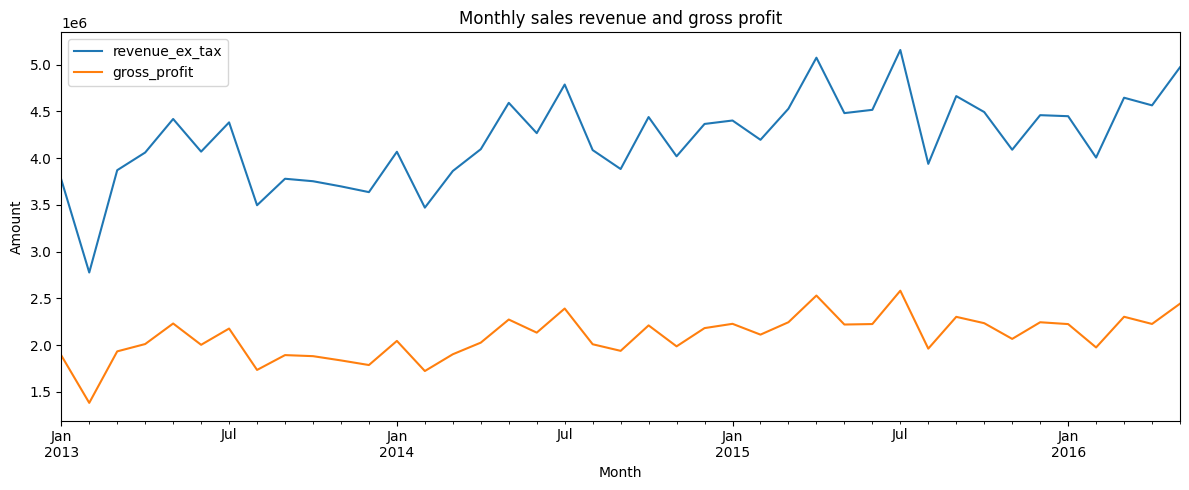

In [44]:
required_sales_tables = {'Sales_InvoiceLines', 'Sales_Invoices'}

if required_sales_tables.issubset(tables):
    invoice_lines = tables['Sales_InvoiceLines'].copy()
    invoices = tables['Sales_Invoices'].copy()
    sales = invoice_lines.merge(
        invoices[['InvoiceID', 'CustomerID', 'InvoiceDate', 'BillToCustomerID']],
        on='InvoiceID',
        how='left',
        validate='many_to_one',
    )
    sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'], errors='coerce')
    sales['invoice_month'] = sales['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
    sales['revenue_ex_tax'] = sales['ExtendedPrice'] - sales['TaxAmount']
    sales['revenue_inc_tax'] = sales['ExtendedPrice']
    sales['gross_profit'] = sales['LineProfit']
    sales['gross_margin_pct'] = np.where(sales['revenue_ex_tax'] != 0, sales['gross_profit'] / sales['revenue_ex_tax'], np.nan)

    metrics = {
        'invoice_line_rows': len(sales),
        'invoice_count': sales['InvoiceID'].nunique(),
        'customer_count': sales['CustomerID'].nunique(),
        'quantity_sold': sales['Quantity'].sum(),
        'revenue_ex_tax': sales['revenue_ex_tax'].sum(),
        'revenue_inc_tax': sales['revenue_inc_tax'].sum(),
        'gross_profit': sales['gross_profit'].sum(),
        'gross_margin_pct': sales['gross_profit'].sum() / sales['revenue_ex_tax'].sum(),
        'min_invoice_date': sales['InvoiceDate'].min(),
        'max_invoice_date': sales['InvoiceDate'].max(),
    }
    display(pd.Series(metrics, name='value').to_frame())

    monthly_sales = sales.groupby('invoice_month', as_index=False).agg(
        revenue_ex_tax=('revenue_ex_tax', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        quantity_sold=('Quantity', 'sum'),
        invoice_count=('InvoiceID', 'nunique'),
    )
    monthly_sales['gross_margin_pct'] = monthly_sales['gross_profit'] / monthly_sales['revenue_ex_tax']
    display(monthly_sales.head())

    ax = monthly_sales.plot(x='invoice_month', y=['revenue_ex_tax', 'gross_profit'], figsize=(12, 5))
    ax.set_title('Monthly sales revenue and gross profit')
    ax.set_xlabel('Month')
    ax.set_ylabel('Amount')
    plt.tight_layout()
    plt.show()

    monthly_sales.to_csv(REPORT_DIR / 'monthly_sales.csv', index=False)
else:
    print(f'Skipped sales EDA. Missing: {sorted(required_sales_tables - set(tables))}')

,StockItemID,revenue_ex_tax,gross_profit,quantity_sold,invoice_lines,gross_margin_pct,StockItemName
214,215,"11,107,251.0000","4,439,391.0000",5849,1061,0.3997,Air cushion machine (Blue)
172,173,"6,384,000.0000","3,526,400.0000",60800,1085,0.5524,32 mm Anti static bubble wrap (Blue) 50m
166,167,"6,329,070.0000","3,452,220.0000",63930,1119,0.5455,10 mm Anti static bubble wrap (Blue) 50m
160,161,"6,214,320.0000","5,293,680.0000",57540,1059,0.8519,20 mm Double sided bubble wrap 50m
163,164,"6,190,240.0000","2,929,310.0000",55270,1004,0.4732,32 mm Double sided bubble wrap 50m
157,158,"5,943,000.0000","2,773,400.0000",56600,1035,0.4667,10 mm Double sided bubble wrap 50m
169,170,"5,795,640.0000","2,670,540.0000",56820,1033,0.4608,20 mm Anti static bubble wrap (Blue) 50m
171,172,"2,900,160.0000","1,510,500.0000",60420,1088,0.5208,32 mm Anti static bubble wrap (Blue) 20m
218,219,"2,871,500.0000","1,378,320.0000",57430,1039,0.4800,Void fill 400 L bag (White) 400L
168,169,"2,468,700.0000","1,316,640.0000",54860,994,0.5333,20 mm Anti static bubble wrap (Blue) 20m


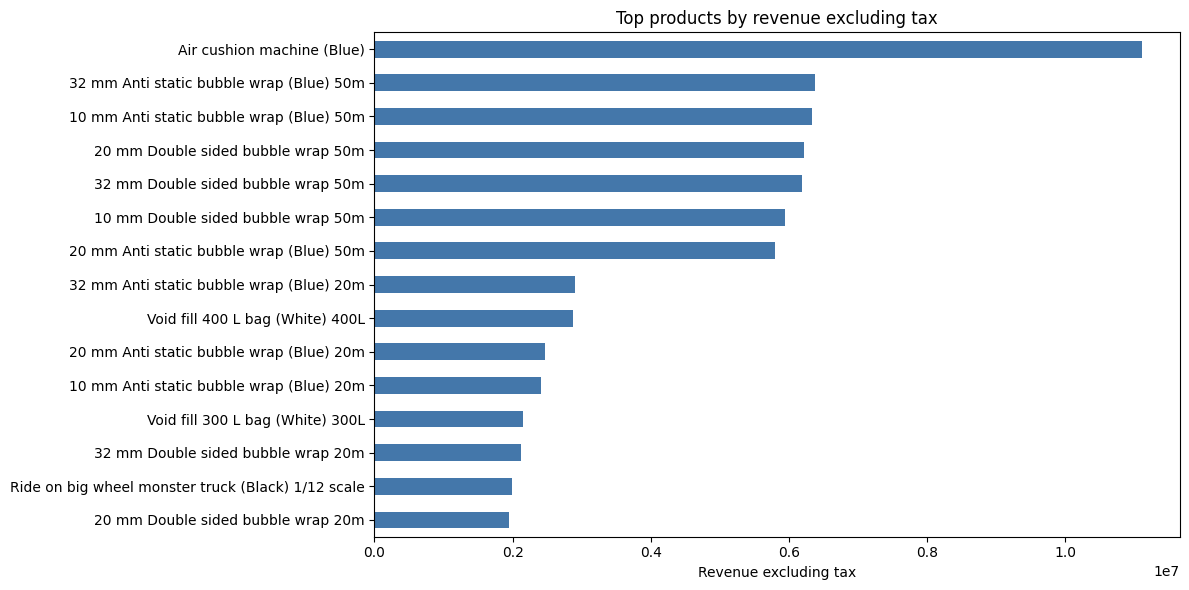

In [45]:
if 'sales' in globals():
    top_products = sales.groupby('StockItemID', as_index=False).agg(
        revenue_ex_tax=('revenue_ex_tax', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        quantity_sold=('Quantity', 'sum'),
        invoice_lines=('InvoiceLineID', 'count'),
    )
    top_products['gross_margin_pct'] = top_products['gross_profit'] / top_products['revenue_ex_tax']

    if 'Warehouse_StockItems' in tables and 'StockItemName' in tables['Warehouse_StockItems'].columns:
        top_products = top_products.merge(
            tables['Warehouse_StockItems'][['StockItemID', 'StockItemName']], on='StockItemID', how='left'
        )

    display(top_products.sort_values('revenue_ex_tax', ascending=False).head(20))

    label_col = 'StockItemName' if 'StockItemName' in top_products.columns else 'StockItemID'
    plot_data = top_products.sort_values('revenue_ex_tax', ascending=False).head(15).sort_values('revenue_ex_tax')
    ax = plot_data.plot.barh(x=label_col, y='revenue_ex_tax', figsize=(12, 6), legend=False, color='#4477AA')
    ax.set_title('Top products by revenue excluding tax')
    ax.set_xlabel('Revenue excluding tax')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    top_products.to_csv(REPORT_DIR / 'top_products.csv', index=False)

In [46]:
if 'sales' in globals():
    top_customers = sales.groupby('CustomerID', as_index=False).agg(
        revenue_ex_tax=('revenue_ex_tax', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        invoice_count=('InvoiceID', 'nunique'),
    )
    top_customers['gross_margin_pct'] = top_customers['gross_profit'] / top_customers['revenue_ex_tax']

    if 'Sales_Customers' in tables and 'CustomerName' in tables['Sales_Customers'].columns:
        top_customers = top_customers.merge(
            tables['Sales_Customers'][['CustomerID', 'CustomerName', 'CustomerCategoryID', 'DeliveryCityID']],
            on='CustomerID',
            how='left',
        )

    display(top_customers.sort_values('revenue_ex_tax', ascending=False).head(20))
    top_customers.to_csv(REPORT_DIR / 'top_customers.csv', index=False)

,CustomerID,revenue_ex_tax,gross_profit,invoice_count,gross_margin_pct,CustomerName,CustomerCategoryID,DeliveryCityID
148,149,"381,585.3500","189,277.4500",126,0.4960,"Tailspin Toys (Inguadona, MN)",3,16557
131,132,"371,822.3000","185,432.5500",125,0.4987,"Tailspin Toys (Minidoka, ID)",3,22453
578,977,"369,058.3000","172,559.8000",115,0.4676,Mauno Laurila,3,24590
380,580,"365,427.0000","188,919.7500",136,0.5170,"Wingtip Toys (Sarversville, PA)",3,30663
555,954,"361,939.7500","181,555.6000",124,0.5016,Nasrin Omidzadeh,4,21161
13,14,"360,901.5000","174,221.4000",117,0.4827,"Tailspin Toys (Long Meadow, MD)",3,19908
565,964,"359,859.4500","189,239.3500",135,0.5259,Ingrida Zeltina,4,34422
272,472,"355,293.3500","185,158.6500",125,0.5211,"Wingtip Toys (San Jacinto, CA)",3,30387
597,996,"354,680.8000","172,134.7500",108,0.4853,Laszlo Gardenier,6,21001
442,841,"353,499.1500","173,946.9500",120,0.4921,Camille Authier,6,15


## 11. Purchasing EDA

,order_month,ordered_amount,ordered_outers,po_count
0,2013-01-01,"474,210.9000",8178,68
1,2013-02-01,"705,372.0000",7693,37
2,2013-03-01,"1,335,183.6000",14552,47
3,2013-04-01,"2,330,617.6000",25963,51
4,2013-05-01,"3,536,868.0000",40298,52


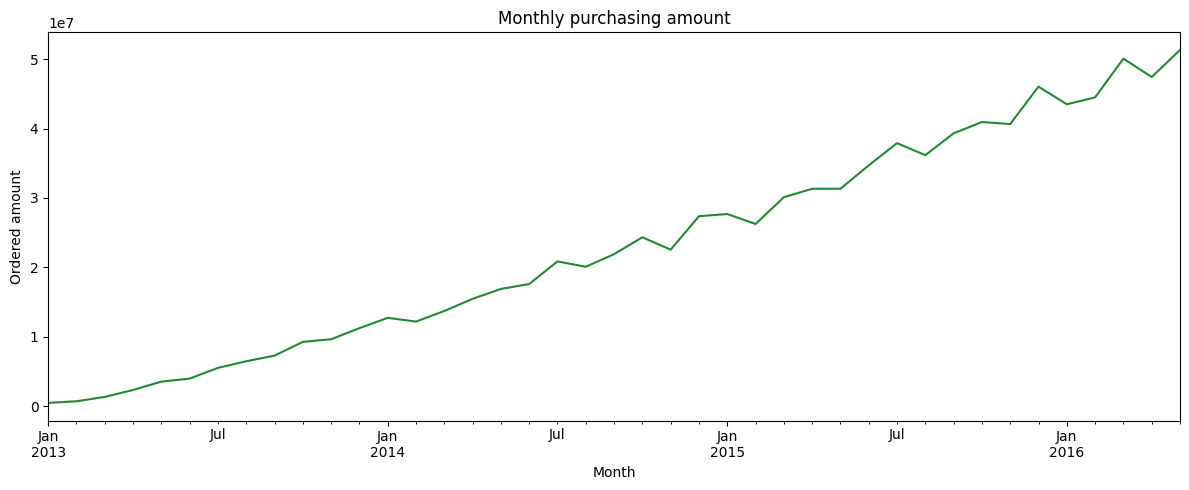

,SupplierID,ordered_amount,po_count,SupplierName
2,4,"679,696,728.0000",1055,"Fabrikam, Inc."
4,7,"266,856,976.5000",985,"Litware, Inc."
5,10,"78,816.5000",10,NaN
6,12,"50,820.0000",5,The Phone Company
0,1,"25,023.0000",5,A Datum Corporation
3,5,"6,489.0000",13,NaN
1,2,313.5000,1,"Contoso, Ltd."


In [47]:
required_purchase_tables = {'Purchasing_PurchaseOrderLines', 'Purchasing_PurchaseOrders'}

if required_purchase_tables.issubset(tables):
    po_lines = tables['Purchasing_PurchaseOrderLines'].copy()
    po = tables['Purchasing_PurchaseOrders'].copy()
    purchasing = po_lines.merge(
        po[['PurchaseOrderID', 'SupplierID', 'OrderDate', 'ExpectedDeliveryDate']],
        on='PurchaseOrderID',
        how='left',
        validate='many_to_one',
    )
    purchasing['OrderDate'] = pd.to_datetime(purchasing['OrderDate'], errors='coerce')
    purchasing['order_month'] = purchasing['OrderDate'].dt.to_period('M').dt.to_timestamp()
    purchasing['ordered_amount'] = purchasing['OrderedOuters'] * purchasing['ExpectedUnitPricePerOuter']

    monthly_purchase = purchasing.groupby('order_month', as_index=False).agg(
        ordered_amount=('ordered_amount', 'sum'),
        ordered_outers=('OrderedOuters', 'sum'),
        po_count=('PurchaseOrderID', 'nunique'),
    )
    display(monthly_purchase.head())

    ax = monthly_purchase.plot(x='order_month', y='ordered_amount', figsize=(12, 5), legend=False, color='#228833')
    ax.set_title('Monthly purchasing amount')
    ax.set_xlabel('Month')
    ax.set_ylabel('Ordered amount')
    plt.tight_layout()
    plt.show()

    supplier_purchase = purchasing.groupby('SupplierID', as_index=False).agg(
        ordered_amount=('ordered_amount', 'sum'),
        po_count=('PurchaseOrderID', 'nunique'),
    )
    if 'Purchasing_Suppliers' in tables and 'SupplierName' in tables['Purchasing_Suppliers'].columns:
        supplier_purchase = supplier_purchase.merge(
            tables['Purchasing_Suppliers'][['SupplierID', 'SupplierName']], on='SupplierID', how='left'
        )
    display(supplier_purchase.sort_values('ordered_amount', ascending=False).head(20))
    monthly_purchase.to_csv(REPORT_DIR / 'monthly_purchase.csv', index=False)
    supplier_purchase.to_csv(REPORT_DIR / 'supplier_purchase.csv', index=False)
else:
    print(f'Skipped purchasing EDA. Missing: {sorted(required_purchase_tables - set(tables))}')

## 12. Warehouse EDA

,StockItemID,movement_quantity,transaction_count,StockItemName
192,193,"25,010,688.0000",1529,Black and orange glass with care despatch tape...
97,98,"18,837,585.0000",1514,"""The Gu"" red shirt XML tag t-shirt (Black) 4XL"
77,78,"18,686,148.0000",1521,"""The Gu"" red shirt XML tag t-shirt (White) XS"
85,86,"18,078,336.0000",1544,"""The Gu"" red shirt XML tag t-shirt (White) 5XL"
76,77,"17,338,224.0000",1532,"""The Gu"" red shirt XML tag t-shirt (White) XXS"
203,204,"11,992,016.0000",1548,Tape dispenser (Red)
183,184,"11,279,700.0000",1457,Shipping carton (Brown) 305x305x305mm
94,95,"9,200,760.0000",1752,"""The Gu"" red shirt XML tag t-shirt (Black) XL"
79,80,"8,590,812.0000",1767,"""The Gu"" red shirt XML tag t-shirt (White) M"
190,191,"-206,892.0000",1041,Black and orange fragile despatch tape 48mmx75m


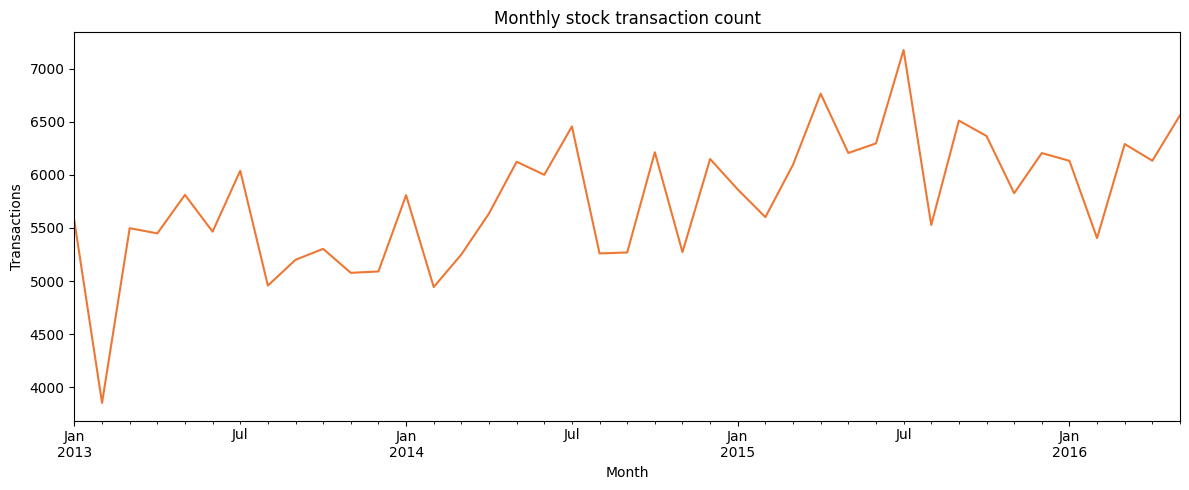

In [48]:
if 'Warehouse_StockItemTransactions' in tables:
    stock_tx = tables['Warehouse_StockItemTransactions'].copy()
    date_col = 'TransactionOccurredWhen' if 'TransactionOccurredWhen' in stock_tx.columns else None
    if date_col:
        stock_tx[date_col] = pd.to_datetime(stock_tx[date_col], errors='coerce')
        stock_tx['transaction_month'] = stock_tx[date_col].dt.to_period('M').dt.to_timestamp()

    movement = stock_tx.groupby('StockItemID', as_index=False).agg(
        movement_quantity=('Quantity', 'sum'),
        transaction_count=('StockItemTransactionID', 'count'),
    )
    if 'Warehouse_StockItems' in tables and 'StockItemName' in tables['Warehouse_StockItems'].columns:
        movement = movement.merge(
            tables['Warehouse_StockItems'][['StockItemID', 'StockItemName']], on='StockItemID', how='left'
        )
    display(movement.reindex(movement['movement_quantity'].abs().sort_values(ascending=False).index).head(20))
    movement.to_csv(REPORT_DIR / 'stock_item_movement.csv', index=False)

    if date_col:
        monthly_movement = stock_tx.groupby('transaction_month', as_index=False).agg(
            movement_quantity=('Quantity', 'sum'),
            transaction_count=('StockItemTransactionID', 'count'),
        )
        ax = monthly_movement.plot(x='transaction_month', y='transaction_count', figsize=(12, 5), legend=False, color='#EE7733')
        ax.set_title('Monthly stock transaction count')
        ax.set_xlabel('Month')
        ax.set_ylabel('Transactions')
        plt.tight_layout()
        plt.show()
else:
    print('Skipped warehouse movement EDA. Missing: Warehouse_StockItemTransactions')

## 13. Data Quality Action List

In [49]:
issues = []

if not load_errors.empty:
    for _, row in load_errors.iterrows():
        issues.append({'severity': 'high', 'area': 'load', 'issue': f"{row['file_name']} failed to load: {row['error']}"})

for _, row in table_summary[table_summary['duplicate_rows'] > 0].iterrows():
    issues.append({'severity': 'medium', 'area': 'duplicates', 'issue': f"{row['table_name']} has {row['duplicate_rows']:,} duplicate full rows"})

for _, row in key_checks[key_checks['status'] == 'review'].iterrows():
    issues.append({'severity': 'high', 'area': 'keys', 'issue': f"{row['table_name']} key review: null rows={row.get('key_null_rows', 0)}, duplicate key rows={row.get('duplicate_key_rows', 0)}"})

for _, row in relationship_checks[relationship_checks['status'] == 'review'].iterrows():
    issues.append({'severity': 'high', 'area': 'relationships', 'issue': f"{row['child_table']}.{row['child_key']} has {row['orphan_rows']:,} orphan rows against {row['parent_table']}.{row['parent_key']}"})

for _, row in missing_columns[missing_columns['missing_pct'] >= 0.5].iterrows():
    issues.append({'severity': 'medium', 'area': 'missing', 'issue': f"{row['table_name']}.{row['column_name']} is {row['missing_pct']:.1%} missing"})

issues = pd.DataFrame(issues)
if issues.empty:
    print('No major data quality issues found by the automated checks.')
else:
    display(issues.sort_values(['severity', 'area']))
    issues.to_csv(REPORT_DIR / 'data_quality_issues.csv', index=False)
    print(f'Saved: {REPORT_DIR / "data_quality_issues.csv"}')

,severity,area,issue
0,high,keys,Application_People_Archive key review: null ro...
1,high,keys,Application_StateProvinces_Archive key review:...
2,high,relationships,Application_StateProvinces.CountryID has 53 or...
3,high,relationships,Purchasing_PurchaseOrders.SupplierID has 23 or...
4,high,relationships,Purchasing_SupplierTransactions.SupplierID has...
5,high,relationships,Warehouse_StockItems.SupplierID has 60 orphan ...
6,medium,missing,Warehouse_VehicleTemperatures.CompressedSensor...
7,medium,missing,Purchasing_PurchaseOrders.Comments is 100.0% m...
8,medium,missing,Sales_SpecialDeals.UnitPrice is 100.0% missing
9,medium,missing,Purchasing_Suppliers_Archive.DeliveryLocation ...


Saved: \reports\eda\data_quality_issues.csv
